# Cafe Sales Analysis
## Business Scenario
You have beeen hired as a junior data analyst by a cafe. The cafe has provided the transaction data and wants to understand its sales perfomance.

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# loading data sets
df=pd.read_csv("C:/Users/SEB/Downloads/PYTHON/PYTHON FOR DATA ANALYTICS & DATA APPS/Dirty Cafe Sales Dataset/dirty_cafe_sales.csv")


In [3]:
#
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [4]:
#
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [5]:
# Dataset sample
df.sample()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
8050,TXN_9320353,Salad,5,5.0,25.0,Cash,In-store,2023-01-10


In [6]:

# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


Our dataset has missing values and some columns has incorrect data types.

In [7]:
#statistical summary
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [8]:
# selecting single columns
df["Item"].head()

0    Coffee
1      Cake
2    Cookie
3     Salad
4    Coffee
Name: Item, dtype: str

In [9]:
# multiple columns
df[['Item','Price Per Unit']].head()

,Item,Price Per Unit
0,Coffee,2.0
1,Cake,3.0
2,Cookie,1.0
3,Salad,5.0
4,Coffee,2.0


In [10]:
# check data type for a specific column
df['Quantity'].dtype

<StringDtype(storage='python', na_value=nan)>

In [11]:
# checking data types
df.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

### Data Quality 

In [12]:
# are there missing values
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [13]:
df.isna().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [14]:
# Duplicated Records
df.duplicated().sum()

np.int64(0)

### Data Cleaning
#### Cleaning Order
    1. Hidden errors 'unkown' & 'Error'
    2. Fix Data Types
    3. Drop Missing Values

In [15]:
# REmove hidden Errors
invalid_values = ['UNKNOWN', 'ERROR', 'NA', '?']

# REPLACE THE INVALID VALUES WITH NAN VALUES ACROSS THE ENTIRE DATA FRAME
df.replace(invalid_values, np.nan, inplace=True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [16]:
#checking missing values
df.isnull().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [17]:
# fix data types
# converting quantity, Price per unit and total spent to numeric
df['Quantity'] = pd.to_numeric(df['Quantity'], errors= 'coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors= 'coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors= 'coerce')


In [18]:
#convert transaction adate  to date
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors= 'coerce' )

In [19]:
# Drop missing values
df = df.dropna()


In [20]:
# Clean text
df['Item'] = df['Item'].str.strip().str.title()

## Validation

In [21]:
# recheck for missing values
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [22]:
# Rechek the shape
df.shape

(3089, 8)

In [23]:
# Rechek th data types
df.dtypes

Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

In [24]:
# rechek summary statistics
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,3089.000000,3089.000000,3089.000000,3089
mean,3.023632,2.954030,8.936711,2023-07-01 07:14:28.242149
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-03-28 00:00:00
50%,3.000000,3.000000,8.000000,2023-07-06 00:00:00
75%,4.000000,4.000000,12.000000,2023-10-01 00:00:00
max,5.000000,5.000000,25.000000,2023-12-31 00:00:00
std,1.418931,1.292975,6.032656,NaN


In [25]:
# Chek item column
df['Item'].unique()

<StringArray>
['Coffee', 'Cake', 'Salad', 'Sandwich', 'Juice', 'Smoothie', 'Cookie', 'Tea']
Length: 8, dtype: str

## Business Questions

In [26]:
# How many transactions does each product have?
df['Item'].value_counts()

Item
Juice       427
Salad       418
Sandwich    391
Cookie      391
Cake        385
Tea         372
Coffee      367
Smoothie    338
Name: count, dtype: int64

In [27]:
# What is the best seller
df['Item'].value_counts().head(1)

Item
Juice    427
Name: count, dtype: int64

In [28]:
# What is the best seller
df['Item'].value_counts().idxmax()

'Juice'

In [29]:
# What is the average quantity per transactio
df['Quantity'].mean()

np.float64(3.0236322434444802)

In [30]:
# What is the total quantity sold?
df['Quantity'].sum()

np.float64(9340.0)

In [31]:
# Creating a new column
df['Revenue'] = df['Quantity'] * df['Price Per Unit']

In [32]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Revenue
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,4.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,12.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,4.0
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07,25.0
12,TXN_7619095,Sandwich,2.0,4.0,8.0,Cash,In-store,2023-05-03,8.0


In [33]:
# What is total revenue?
df['Revenue'].sum()

np.float64(27605.5)

In [34]:
# what is the average revenue per transaction?
df['Revenue'].mean()

np.float64(8.936710909679508)

In [35]:
# Which products/ items generate the most revenue?
df.groupby('Item')['Revenue'].sum().sort_values(ascending=False)

Item
Salad       6360.0
Sandwich    4772.0
Smoothie    4088.0
Juice       3735.0
Cake        3519.0
Coffee      2242.0
Tea         1726.5
Cookie      1163.0
Name: Revenue, dtype: float64

In [36]:
# Find the average quantity ordered per location
df.groupby('Location')['Quantity'].sum()

Location
In-store    4674.0
Takeaway    4666.0
Name: Quantity, dtype: float64

## Visualizations

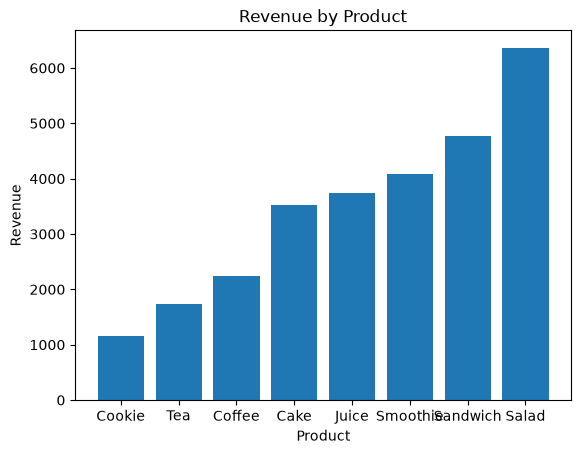

In [42]:
# sales by item
sales_by_item = df.groupby( 'Item' )[ 'Revenue' ].sum().sort_values()

plt.bar(sales_by_item.index, sales_by_item.values)

plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.show()

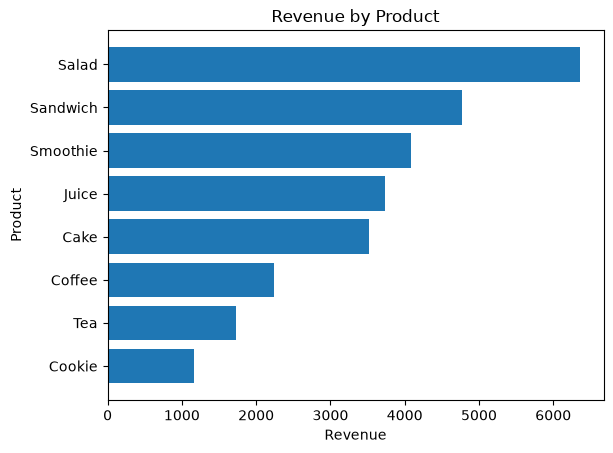

In [43]:
# Horizontal bar chart
plt.barh(sales_by_item.index, sales_by_item.values)
plt.title('Revenue by Product')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.show()

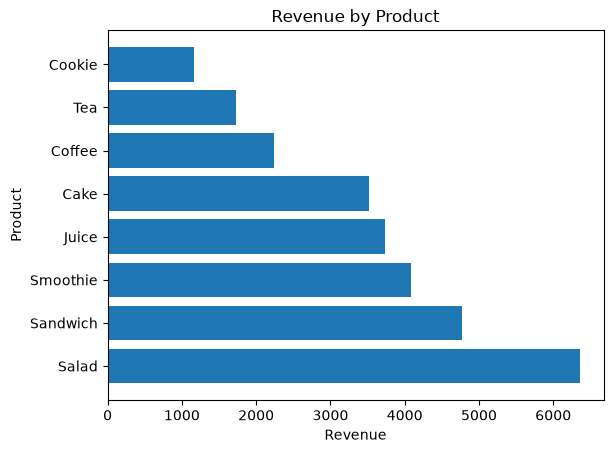

In [44]:
# Horizontal bar chart
plt.barh(sales_by_item.index[:: -1], sales_by_item.values[::-1])
plt.title('Revenue by Product')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.show()

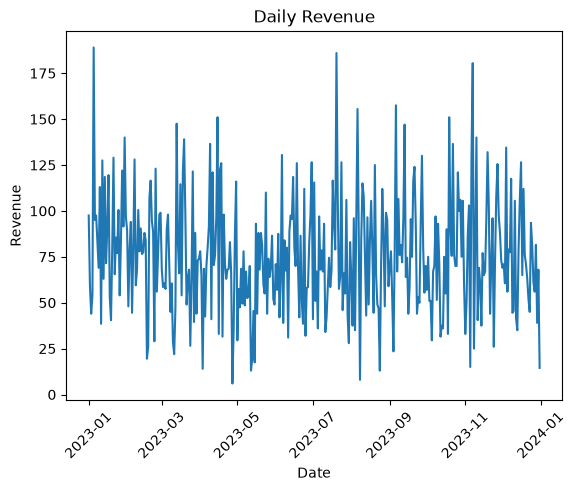

In [48]:
# show sales over time
daily_sales = df.groupby('Transaction Date')['Revenue'].sum()
plt.plot(daily_sales.index, daily_sales.values)

plt.title('Daily Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.show()

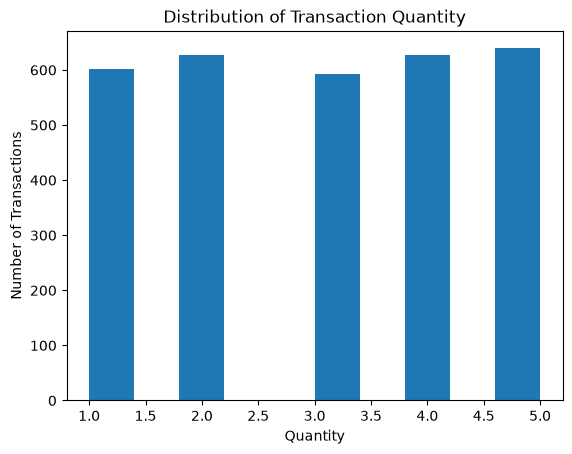

In [49]:
# How are transaction quantities distributed?
plt.hist(df['Quantity'], bins=10)

plt.title('Distribution of Transaction Quantity')
plt.xlabel('Quantity')
plt.ylabel('Number of Transactions')
plt.show()

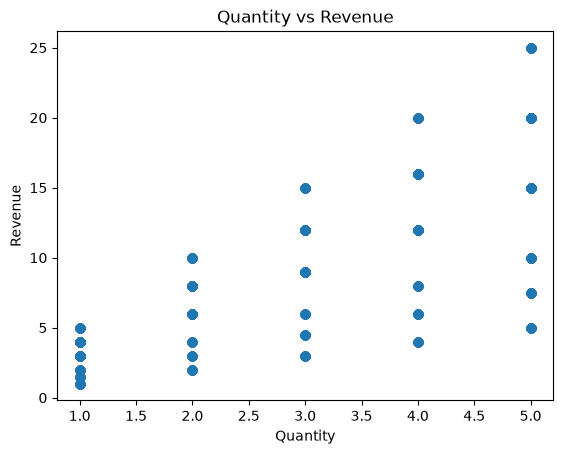

In [50]:
# Is there a relationship between quantity & revenue?
plt.scatter(df['Quantity'], df['Revenue' ])

plt.title('Quantity vs Revenue')
plt.xlabel('Quantity')
plt.ylabel('Revenue')

plt.show()